<a href="https://colab.research.google.com/github/Thota-Akhilasri/OIBSIP/blob/main/Akhilasri_Thota_Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
##objective: Train a machine learning model to identify iris species from physical measurements
#Step-1: Import a libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print("First 5 rows:")
print("\nShape of dataset:", df.shape)
df.head()

First 5 rows:

Shape of dataset: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [41]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [43]:
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
123,6.3,2.7,4.9,1.8,virginica
86,6.7,3.1,4.7,1.5,versicolor
68,6.2,2.2,4.5,1.5,versicolor
7,5.0,3.4,1.5,0.2,setosa
56,6.3,3.3,4.7,1.6,versicolor


In [42]:
#Exploratory Data Analysis
print("Dataset shape:", df.shape)
print("\nColumn names:")
df.columns
print("\nDataset info:")
df.info()
print("\nMissing values:")
df.isnull().sum()

Dataset shape: (150, 5)

Column names:

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

Missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [44]:
# Summary Statistics
print("\nSummary statistics:")
df.describe()


Summary statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


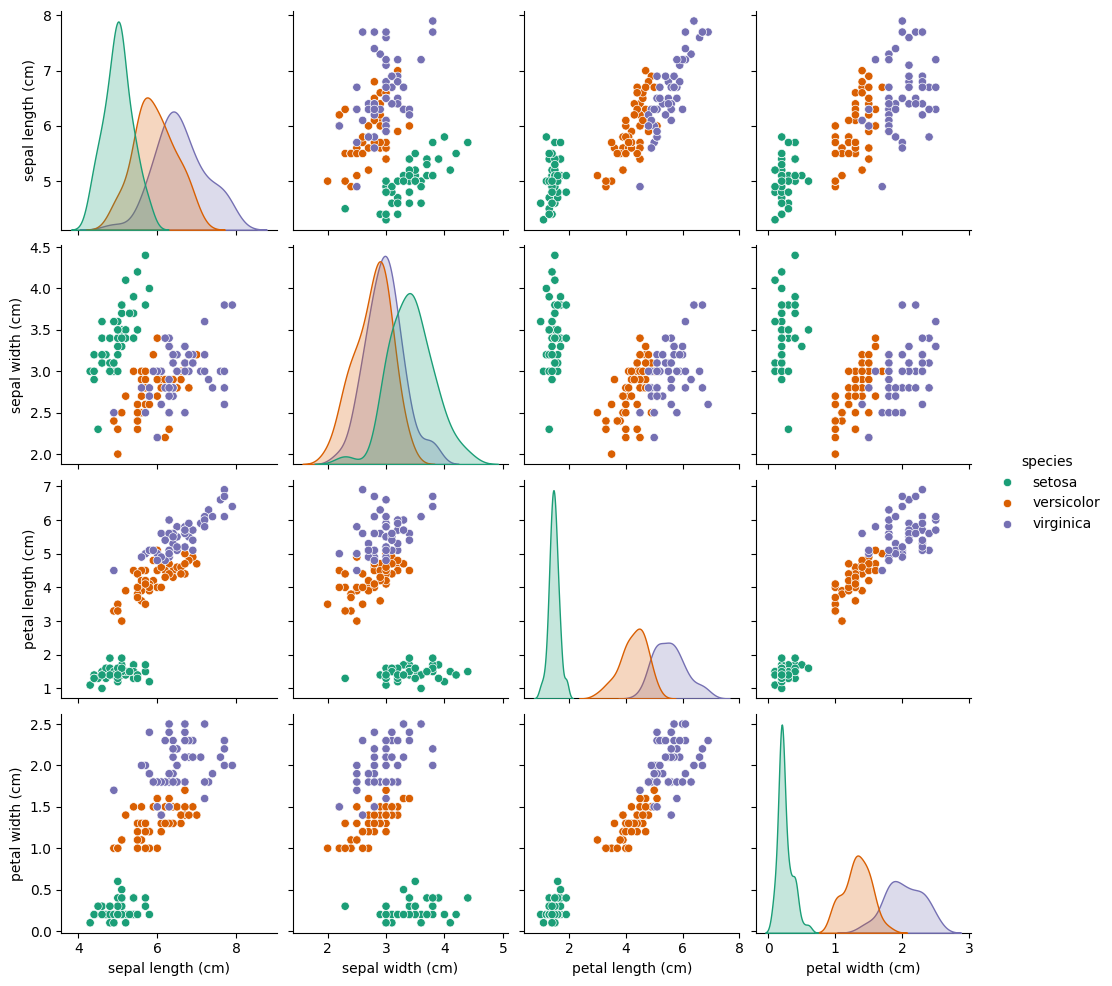

In [45]:
#Visualisation a pairplot
sns.pairplot(df, hue='species', palette='Dark2')
plt.show()

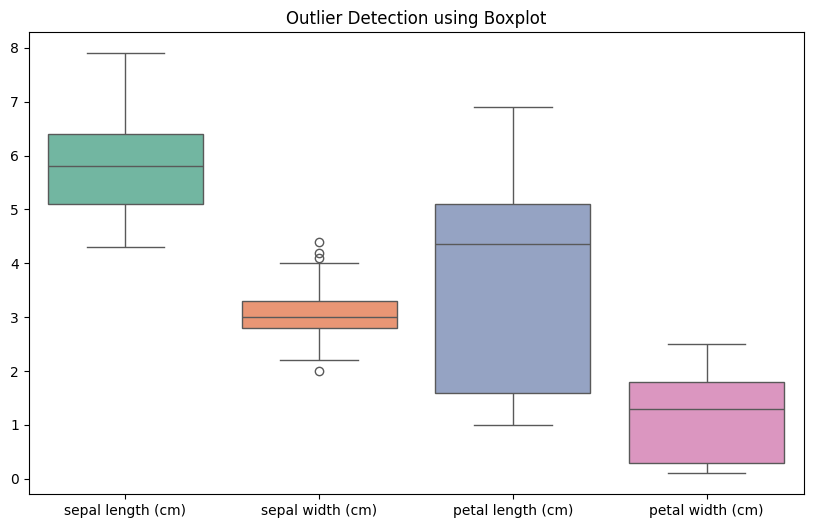

In [46]:
#Visualisation a boxplot for a each feature
plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop('species', axis=1),palette='Set2')
plt.title("Outlier Detection using Boxplot")
plt.show()

In [47]:
#Feature selection
from sklearn.model_selection import train_test_split
features = df.drop("species", axis=1)
target = df["species"]
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature set shape: (120, 4)
Testing feature set shape: (30, 4)
Training target shape: (120,)
Testing target shape: (30,)


In [48]:
#Train a two different classifiers i.e Logistic Regression and Decision Tree
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
#1.Logistic Regression
lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_preds)
#2. Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
#combine two classifiers
print("=" * 45)
print(f"Logistic Regression Accuracy : {lr_acc * 100:.2f}%")
print(f"Decision Tree Accuracy : {dt_acc * 100:.2f}%")
print("=" * 45)

Logistic Regression Accuracy : 100.00%
Decision Tree Accuracy : 100.00%


In [49]:
#Evaluate a each model
from sklearn.metrics import classification_report, confusion_matrix
print("=" * 20 + " 1 . Logistic Regression Report " + "=" * 20)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_preds))
print("\nClassification Report:")
print(classification_report(y_test,lr_preds))
print("\n" + "=" * 20 + " 2. Decision Tree Report " + "=" * 20)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_preds))
print("\nClassification_report:")
print(classification_report(y_test,dt_preds))

==================== 1 . Logistic Regression Report ====================

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


==================== 2. Decision Tree Report ====================

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification_report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00    

In [50]:
#Identify and declare the best performing models with justification
print("=" * 30 + " FINAL CONCLUSION " + "=" * 30)
print("Best Performing Model: Both Logistic Regression & Decision Tree")
print("-" * 78)
print("Justification:")
print("1. Both models achieved a perfect accuracy of 100.00% on the testing dataset.")
print("2. The Precision, Recall, and F1-score for all three iris species are 1.00.")
print("3. Since the Iris dataset is small, clean, and linearly separable, both linear")
print(" models (Logistic Regression) and tree-based models (Decision Tree) can ")
print(" easily classify the flower species without any errors.")
print("4. However, for future scalability with larger datasets, Logistic Regression ")
print(" is preferred for less risk of overfitting, while Decision Tree is ")
print(" preferred for better interpretability.")
print("=" * 78)

============================== FINAL CONCLUSION ==============================
Best Performing Model: Both Logistic Regression & Decision Tree
------------------------------------------------------------------------------
Justification:
1. Both models achieved a perfect accuracy of 100.00% on the testing dataset.
2. The Precision, Recall, and F1-score for all three iris species are 1.00.
3. Since the Iris dataset is small, clean, and linearly separable, both linear
 models (Logistic Regression) and tree-based models (Decision Tree) can 
 easily classify the flower species without any errors.
4. However, for future scalability with larger datasets, Logistic Regression 
 is preferred for less risk of overfitting, while Decision Tree is 
 preferred for better interpretability.
